In [1]:
# 0. Установка и импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

# 1. Загрузка данных

DATA_PATH = "/content/drive/MyDrive/Data/Задание+7+restaurants.csv"

df = pd.read_csv(DATA_PATH)
print("Размер датасета:", df.shape)
display(df.head())
display(df.info())
print("\nПропуски по столбцам:")
display(df.isnull().sum())


Размер датасета: (6593, 8)


,Name,Location,Locality,City,Cuisine,Rating,Votes,Cost
0,Local,"Scindia House,Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Finger Food, Continental",4.1,2415,2000
1,The G.T. ROAD,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,North Indian,4.3,2363,1500
2,Tamasha,"Connaught Place, Central Delhi",Central Delhi,Delhi,"Finger Food, North Indian, Italian, Contine...",4.2,5016,2000
3,The Junkyard Cafe,"Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Mediterranean, Asian, Italian...",4.2,2821,1800
4,Chili's American Grill and Bar,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,"Mexican, American, Italian",4.4,1094,2000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6593 entries, 0 to 6592
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      6593 non-null   object 
 1   Location  6593 non-null   object 
 2   Locality  6593 non-null   object 
 3   City      6593 non-null   object 
 4   Cuisine   6593 non-null   object 
 5   Rating    6593 non-null   float64
 6   Votes     6593 non-null   int64  
 7   Cost      6593 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 412.2+ KB


None


Пропуски по столбцам:


,0
Name,0
Location,0
Locality,0
City,0
Cuisine,0
Rating,0
Votes,0
Cost,0


In [9]:
# Поиск дубоикатов
df[df.duplicated()]

,Name,Location,Locality,City,Cuisine,Rating,Votes,Cost
2205,Sandwichwallas,"Jayanagar, South Bangalore",South Bangalore,Bangalore,"Fast Food, Pizza, Shakes",5.0,2,300
2505,Jeff's,"Hotel Royal Orchid,Old Airport Road, East Bang...",East Bangalore,Bangalore,Continental,4.2,27,2500
4864,The Chennai Dhaba,"Baghajatin, South Kolkata",South Kolkata,Kolkata,South Indian,1.0,1,300


In [10]:
# Удаление дубликатов
df = df.drop_duplicates()
df

,Name,Location,Locality,City,Cuisine,Rating,Votes,Cost
0,Local,"Scindia House,Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Finger Food, Continental",4.1,2415,2000
1,The G.T. ROAD,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,North Indian,4.3,2363,1500
2,Tamasha,"Connaught Place, Central Delhi",Central Delhi,Delhi,"Finger Food, North Indian, Italian, Contine...",4.2,5016,2000
3,The Junkyard Cafe,"Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Mediterranean, Asian, Italian...",4.2,2821,1800
4,Chili's American Grill and Bar,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,"Mexican, American, Italian",4.4,1094,2000
...,...,...,...,...,...,...,...,...
6588,Shree Rathnam,"Wave Mall,BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,South Indian,4.1,20,600
6589,Cafe Delish,"Radisson Blu,Rajguru Nagar, West Ludhiana",West Ludhiana,Ludhiana,"Multi-Cuisine, North Indian, Continental, A...",4.4,48,3100
6590,3 K Resorts,"BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,North Indian,1.0,1,1100
6591,Dovka Bar,"Nirvana Hotel Banquets Club,PAU, Central Ludhiana",Central Ludhiana,Ludhiana,"North Indian, Chinese, Finger Food",4.3,3,1500


In [2]:
# 2. Информация по таргетному столбцу.

target = 'Rating'
print(f"\n🎯 Таргетный столбец: {target}")
display(df[target].describe())


🎯 Таргетный столбец: Rating


,Rating
count,6593.000000
mean,4.088200
std,0.670031
min,1.000000
25%,3.900000
50%,4.200000
75%,4.400000
max,5.000000


In [21]:
# 3. Предобработка данных

# Разделим признаки по типам
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

df_proc = df.copy()

# Приводим категориальные признаки к типу - строки
for c in cat_cols:
    df_proc[c] = df_proc[c].astype(str)

# Определяем способ кодирования
total_unique = sum(df_proc[c].nunique() for c in cat_cols)
max_ohe = 40
if total_unique <= max_ohe:
    print("\nИспользуем One-Hot Encoding (категорий немного).")
    df_cat = pd.get_dummies(df_proc[cat_cols], drop_first=True)
    df_model = pd.concat([df_proc[num_cols], df_cat, df_proc[[target]]], axis=1)
else:
    print("\nКатегорий много → используем Label Encoding.")
    for c in cat_cols:
        df_proc[c] = LabelEncoder().fit_transform(df_proc[c])
    df_model = df_proc[num_cols + cat_cols + [target]]

print("Размер обработанного датасета:", df_model.shape)
display(df_model.head())

Числовые признаки: ['Votes', 'Cost']
Категориальные признаки: ['Name', 'Location', 'Locality', 'City', 'Cuisine']

Категорий много → используем Label Encoding.
Размер обработанного датасета: (6590, 8)


,Votes,Cost,Name,Location,Locality,City,Cuisine,Rating
0,2415,2000,2239,1796,11,5,1707,4.1
1,2363,1500,3904,1149,11,5,1394,4.3
2,5016,2000,3632,370,11,5,687,4.2
3,2821,1800,3959,370,11,5,1809,4.2
4,1094,2000,890,1149,11,5,993,4.4


🔹 Корреляции признаков с рейтингом:


,Rating
Rating,1.000000
Cost,0.149477
Votes,0.094167
Locality,0.002087
City,-0.006977
Location,-0.010482
Name,-0.012144
Cuisine,-0.027200


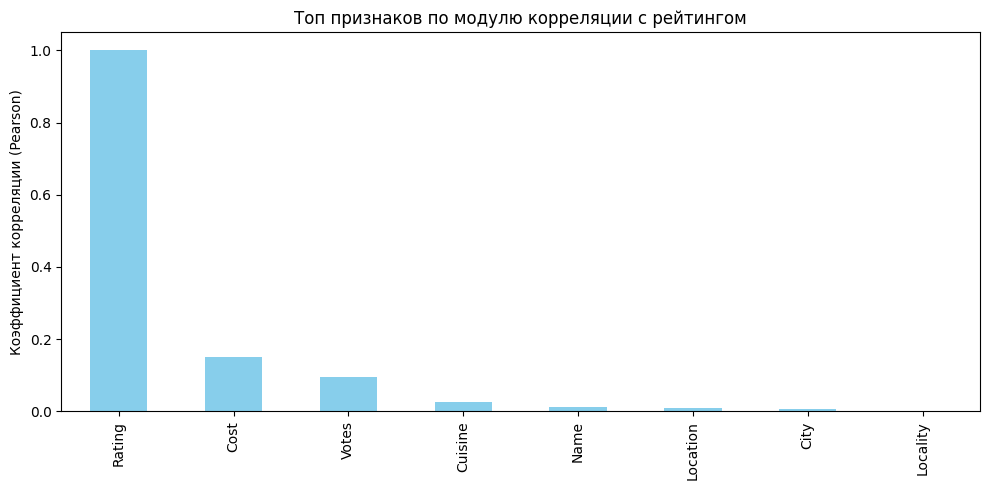

In [24]:
# 4. Корреляции признаков с таргетом

corr = df_model.corr()[target].sort_values(ascending=False)
print("🔹 Корреляции признаков с рейтингом:")
display(corr)

# Визуализация
plt.figure(figsize=(10,5))
corr.abs().sort_values(ascending=False).head(10).plot.bar(color='skyblue')
plt.title("Топ признаков по модулю корреляции с рейтингом")
plt.ylabel("Коэффициент корреляции (Pearson)")
plt.tight_layout()
plt.show()

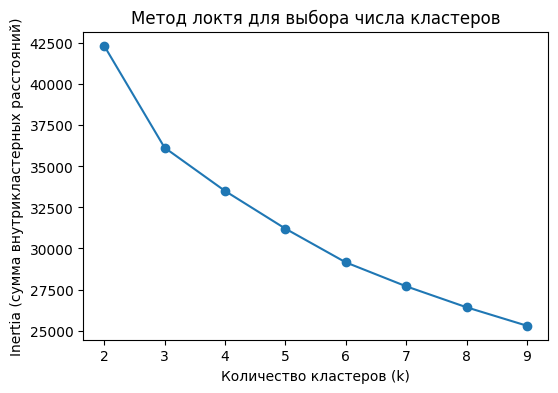

In [29]:
# 5. Кластеризация (поиск групп ресторанов)

# Масштабирование признаков
features_for_cluster = df_model.drop(columns=[target]).select_dtypes(include=[np.number]).columns
Xc = StandardScaler().fit_transform(df_model[features_for_cluster])

# Определение оптимального числа кластеров (метод "локтя")
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(Xc)
    inertias.append(kmeans_tmp.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.title("Метод локтя для выбора числа кластеров")
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Inertia (сумма внутрикластерных расстояний)")
plt.show()



In [31]:
# Определяем оптимальное число кластеров (точка на изломе)
# место с максимальным изменением угла (вторая производная)
diff1 = np.diff(inertias)
diff2 = np.diff(diff1)
k_opt = K_range[np.argmin(diff2) + 1]
print(f"🔹 Оптимальное число кластеров (по методу локтя): {k_opt}")

 Оптимальное число кластеров (по методу локтя): 8


In [ ]:
# Кластеризация
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(Xc)

print("📦 Распределение по кластерам:")
display(df_model['cluster'].value_counts())

# --- Корреляции внутри каждого кластера ---
for cl in range(k_opt):
    sub = df_model[df_model['cluster'] == cl].drop(columns=['cluster'])
    c = sub.corr()[target].sort_values(ascending=False)
    print(f"\nКластер {cl} (n={len(sub)}): топ 5 положительных и отрицательных корреляций")
    display(pd.concat([c.head(5), c.tail(5)]))

In [33]:
# Кластеризация
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(Xc)

print(" Распределение по кластерам:")
display(df_model['cluster'].value_counts())


 Распределение по кластерам:


,count
cluster,
4,1094
6,1038
7,901
0,883
5,854
3,854
1,815
2,151


In [34]:
# --- Корреляции внутри каждого кластера ---
for cl in range(k_opt):
    sub = df_model[df_model['cluster'] == cl].drop(columns=['cluster'])
    c = sub.corr()[target].sort_values(ascending=False)
    print(f"\nКластер {cl} (n={len(sub)}): топ 5 положительных и отрицательных корреляций")
    display(pd.concat([c.head(5), c.tail(5)]))


Кластер 0 (n=883): топ 5 положительных и отрицательных корреляций


,Rating
Rating,1.000000
Cost,0.135586
Votes,0.133704
Cuisine,0.033967
Locality,0.024010
Cuisine,0.033967
Locality,0.024010
Location,0.015744
Name,-0.024351
City,-0.027649



Кластер 1 (n=815): топ 5 положительных и отрицательных корреляций


,Rating
Rating,1.000000
Votes,0.138461
Cost,0.102106
Cuisine,0.054773
Locality,0.036641
Cuisine,0.054773
Locality,0.036641
Name,0.033665
City,0.007293
Location,-0.040160



Кластер 2 (n=151): топ 5 положительных и отрицательных корреляций


...

,Rating
Rating,1.000000
Cost,0.144032
Votes,0.120872
Cuisine,0.099712
Locality,0.028372
Cuisine,0.099712
Locality,0.028372
City,0.012456
Location,-0.018463
Name,-0.029718



Кластер 6 (n=1038): топ 5 положительных и отрицательных корреляций


,Rating
Rating,1.000000
Votes,0.091276
Cost,0.083174
Locality,0.021229
Location,0.008528
Locality,0.021229
Location,0.008528
Name,-0.001367
City,-0.019665
Cuisine,-0.140882



Кластер 7 (n=901): топ 5 положительных и отрицательных корреляций


,Rating
Rating,1.000000
Cost,0.144885
Votes,0.114533
Cuisine,0.030750
Locality,0.001132
Cuisine,0.030750
Locality,0.001132
City,-0.006910
Location,-0.013884
Name,-0.037230


In [36]:
# 6. Моделирование (Linear Regression и Random Forest)

X = df_model.drop(columns=[target, 'cluster'])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Линейная регрессия ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Приводим к float для избежания TypeError
y_true_lr = pd.to_numeric(np.ravel(y_test), errors='coerce')
y_pred_lr = pd.to_numeric(np.ravel(y_pred_lr), errors='coerce')

r2_lr = r2_score(y_true_lr, y_pred_lr)
# Вычисляем RMSE
mse_lr = mean_squared_error(y_true_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print(f"📈 Линейная регрессия: R² = {r2_lr:.3f}, RMSE = {rmse_lr:.3f}")

# --- Случайный лес ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Вычисление метрик
y_true_rf = pd.to_numeric(np.ravel(y_test), errors='coerce')
y_pred_rf = pd.to_numeric(np.ravel(y_pred_rf), errors='coerce')

r2_rf = r2_score(y_true_rf, y_pred_rf)

# Вычисляем RMSE
mse_rf = mean_squared_error(y_true_rf, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"🌲 Random Forest: R² = {r2_rf:.3f}, RMSE = {rmse_rf:.3f}")

📈 Линейная регрессия: R² = 0.025, RMSE = 0.657
🌲 Random Forest: R² = 0.071, RMSE = 0.642


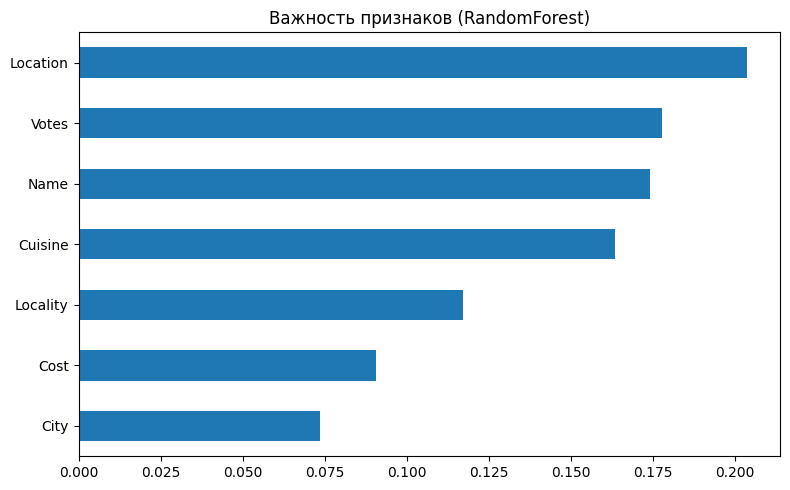

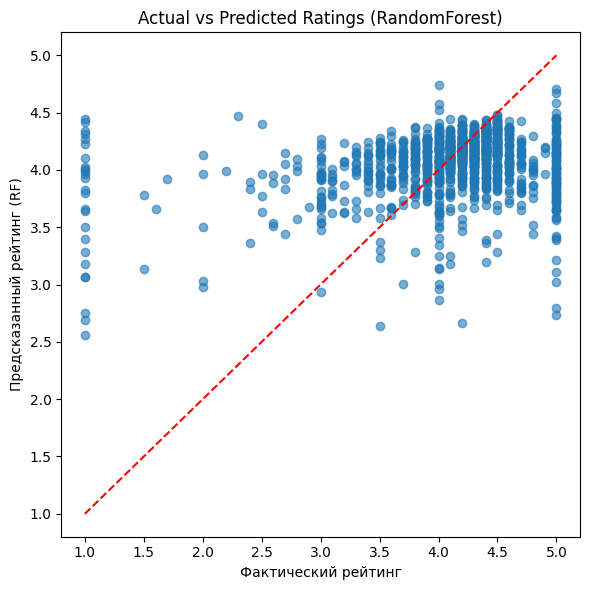

In [53]:
# 7. Важность признаков (feature importance)

# Визуализация
plt.figure(figsize=(8,5))
importances.head(10).plot.barh()
plt.title("Важность признаков (RandomForest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Scatter: фактический vs предсказанный рейтинг
plt.figure(figsize=(6,6))
plt.scatter(y_true_rf, y_pred_rf, alpha=0.6)
lims = [min(y_true_rf.min(), y_pred_rf.min()), max(y_true_rf.max(), y_pred_rf.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel("Фактический рейтинг")
plt.ylabel("Предсказанный рейтинг (RF)")
plt.title("Actual vs Predicted Ratings (RandomForest)")
plt.tight_layout()
plt.show()


In [44]:
# 8. Сохранение и выводы

out_path = "/content/drive/MyDrive/Data/Задание+7+restaurants_analysis_results.csv"
df_out = df.copy()
df_out['cluster'] = df_model['cluster']
df_out['pred_rating_rf'] = rf.predict(X)
df_out.to_csv(out_path, index=False)

print(f"\n✅ Результаты сохранены в файл: {out_path}")

print("\n📋 Выводы:")
print(f"Лучшая модель — RandomForest (R² = {r2_rf:.3f}), она объясняет вариацию рейтинга лучше линейной.")
print("\n Степень влияния признаков на рейтинг по убыванию:")
print("   - местоположение (Location)")
print("   — количеством голосов (Votes),")
print("   — имя (Name) - раскрученность бренда,")
print("   — типом кухни (Cuisine),")
print("   — населенный пункт (Locality),")
print("   — стоимостью (Cost).")




✅ Результаты сохранены в файл: /content/drive/MyDrive/Data/Задание+7+restaurants_analysis_results.csv

📋 Выводы:
Лучшая модель — RandomForest (R² = 0.071), она объясняет вариацию рейтинга лучше линейной.

 Степень влияния признаков на рейтинг по убыванию:
   - местоположение (Location)
   — количеством голосов (Votes),
   — имя (Name) - раскрученность бренда,
   — типом кухни (Cuisine),
   — населенный пункт (Locality),
   — стоимостью (Cost).
